>[Випадкові процеси та їх застосування в аналізі даних](#scrollTo=jlG03TFH0Pfl)

>>>[Ланцюги Маркова](#scrollTo=Ka9FHbm1pX_7)

>>>>[Матриця переходів](#scrollTo=QQEHZYs0AfcP)

>>[Ланцюги Маркова в обробці природної мови (Natural Language Processing, NLP)](#scrollTo=tRr08hHao6iS)

>>>[Алгоритм ланцюга Маркова для генерації речень](#scrollTo=FtBYSPuP7Mai)

>>>>[simple](#scrollTo=TpCYzOWmsn1j)

>>>>[more complex](#scrollTo=5CpMLsb5srOB)

>>>[Марковські процеси ухвалення рішень (Markov decision process, MDP)](#scrollTo=RBFEDlnj7LWa)

>>>[Елементи марковських процесів ухвалення рішень](#scrollTo=Jnbvhhpb7Jpa)

>>[Рівняння Беллмана та оптимальність](#scrollTo=BZuS4SrD7I8Z)

>>>[Розв'язання рівняння Беллмана](#scrollTo=lanldjn1-3BT)

>>>>[Визначення параметрів:](#scrollTo=_Ct7KRFt-6L6)

>>>>[Ініціалізація функції вартості:](#scrollTo=i6JibNQ6m-lM)

>>>>[Покрокове оновлення функції вартості:](#scrollTo=KCU_nJ9am462)

>>>>[Пошук оптимальної стратегії](#scrollTo=GkMGMpVTmx4X)

>>[Задачі про замерзле озеро](#scrollTo=jzdVl-lU-1Ie)

>>>>[2](#scrollTo=Hn35GcVL5y3U)

>[Додаткові матеріали](#scrollTo=_UhpeyIRZTYa)



# Випадкові процеси та їх застосування в аналізі даних




### Ланцюги Маркова

In [ ]:
import numpy as np

class MarkovChain(object):
    def __init__(self, transition_prob):
        """
        Initialize the MarkovChain instance.

        Parameters
        ----------
        transition_prob: dict
            A dict object representing the transition
            probabilities in Markov Chain.
            Should be of the form:
                {'state1': {'state1': 0.1, 'state2': 0.4},
                 'state2': {...}}
        """
        self.transition_prob = transition_prob
        self.states = list(transition_prob.keys())

    def next_state(self, current_state):
        """
        Returns the state of the random variable at the next time
        instance.

        Parameters
        ----------
        current_state: str
            The current state of the system.
        """
        return np.random.choice(
            self.states,
            p=[self.transition_prob[current_state][next_state]
               for next_state in self.states]
        )

    def generate_states(self, current_state, no=10):
        """
        Generates the next states of the system.

        Parameters
        ----------
        current_state: str
            The state of the current random variable.

        no: int
            The number of future states to generate.
        """
        future_states = []
        for i in range(no):
            next_state = self.next_state(current_state)
            future_states.append(next_state)
            current_state = next_state
        return future_states

In [2]:
transition_prob = {'Sunny': {'Sunny': 0.8, 'Rainy': 0.19,
 'Snowy': 0.01},
 'Rainy': {'Sunny': 0.2, 'Rainy': 0.7,
 'Snowy': 0.1},
 'Snowy': {'Sunny': 0.5, 'Rainy': 0.2,
 'Snowy': 0.3}}

In [3]:
print(transition_prob.keys())

dict_keys(['Sunny', 'Rainy', 'Snowy'])


In [ ]:
weather_chain = MarkovChain(transition_prob=transition_prob)

In [ ]:
weather_chain.next_state(current_state='Sunny')

np.str_('Sunny')

In [ ]:
weather_chain.next_state(current_state='Snowy')

np.str_('Sunny')

In [ ]:
weather_chain.generate_states(current_state='Snowy', no=10)

[np.str_('Sunny'),
 np.str_('Rainy'),
 np.str_('Snowy'),
 np.str_('Rainy'),
 np.str_('Sunny'),
 np.str_('Sunny'),
 np.str_('Rainy'),
 np.str_('Rainy'),
 np.str_('Rainy'),
 np.str_('Sunny')]

#### Матриця переходів


In [ ]:
import numpy as np

class MarkovChain(object):
    def __init__(self, transition_matrix, states):
        """
        Initialize the MarkovChain instance.

        Parameters
        ----------
        transition_matrix: 2-D array
            A 2-D array representing the probabilities of change of
            state in the Markov Chain.

        states: 1-D array
            An array representing the states of the Markov Chain. It
            needs to be in the same order as transition_matrix.
        """
        self.transition_matrix = np.atleast_2d(transition_matrix)
        self.states = states
        self.index_dict = {self.states[index]: index for index in
                           range(len(self.states))}
        self.state_dict = {index: self.states[index] for index in
                           range(len(self.states))}

    def next_state(self, current_state):
        """
        Returns the state of the random variable at the next time
        instance.

        Parameters
        ----------
        current_state: str
            The current state of the system.
        """
        return np.random.choice(
         self.states,
         p=self.transition_matrix[self.index_dict[current_state], :]
        )

    def generate_states(self, current_state, no=10):
        """
        Generates the next states of the system.

        Parameters
        ----------
        current_state: str
            The state of the current random variable.

        no: int
            The number of future states to generate.
        """
        future_states = []
        for i in range(no):
            next_state = self.next_state(current_state)
            future_states.append(next_state)
            current_state = next_state
        return future_states


In [ ]:
transition_matrix = [[0.7, 0.2, 0.1],
                         [0.2,  0.7,  0.1],
                         [0.1,  0.2,  0.7]]

In [ ]:
weather_chain = MarkovChain(transition_matrix=transition_matrix,
                                states=['Sunny', 'Rainy', 'Snowy'])

In [ ]:
weather_chain.next_state(current_state='Sunny')

np.str_('Rainy')

In [ ]:
weather_chain.next_state(current_state='Snowy')

np.str_('Snowy')

In [ ]:
weather_chain.generate_states(current_state='Snowy', no=10)

[np.str_('Snowy'),
 np.str_('Snowy'),
 np.str_('Snowy'),
 np.str_('Snowy'),
 np.str_('Snowy'),
 np.str_('Rainy'),
 np.str_('Sunny'),
 np.str_('Rainy'),
 np.str_('Rainy'),
 np.str_('Rainy')]

## Ланцюги Маркова в обробці природної мови (Natural Language Processing, NLP)



### Алгоритм ланцюга Маркова для генерації речень


#### simple

In [6]:
import random

# Зразок корпусу тексту
corpus = """
Твої очі, як те море
Супокійне, світляне;
Серця мого давнє горе,
Мов пилинка, в них тоне.

Твої очі, мов криниця
Чиста на перловім дні,
А надія, мов зірниця,
З них проблискує мені.

Одну я любив за веселість,
Другу я за вроду кохав,
А третій за соняшний усміх
Квітками дорогу встилав.

Ти зовсім була не вродлива
І завжди, як вечір, смутна…
Чого ж ти з усіх моїх милих
У серці осталась одна?!.
"""

# Побудова моделі Ланцюга Маркова
def build_markov_model(corpus):
    words = corpus.split()
    model = {}
    for i in range(len(words)-1):
        if words[i] not in model:
            model[words[i]] = []
        model[words[i]].append(words[i+1])
    return model

# Генерація тексту на основі моделі Ланцюга Маркова
def generate_text(model, length=10):
    current_word = random.choice(list(model.keys()))
    text = current_word
    for _ in range(length-1):
        if current_word in model:
            next_word = random.choice(model[current_word])
            text += " " + next_word
            current_word = next_word
        else:
            break
    return text

# Побудова моделі
model = build_markov_model(corpus)

# Генерація нового тексту
new_text = generate_text(model, length=10)
print(new_text)


смутна… Чого ж ти з усіх моїх милих У серці


#### more complex

In [ ]:
!wget -O data.zip https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/sherlock.zip?raw=true

--2025-09-09 17:09:28--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/sherlock.zip?raw=true
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/refs/heads/main/sherlock.zip [following]
--2025-09-09 17:09:28--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/refs/heads/main/sherlock.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/refs/heads/main/sherlock.zip [following]
--2025-09-09 17:09:29--  https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/refs/heads/main/sherlock.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.

In [ ]:
!unzip data.zip -d data

In [ ]:
import numpy as np
import pandas as pd
import os
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import random
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
story_path = "./data/sherlock/sherlock/"

def read_all_stories(story_path):
    txt = []
    for _, _, files in os.walk(story_path):
        for file in files:
            with open(story_path+file) as f:
                for line in f:
                    line = line.strip()
                    if line=='----------': break
                    if line!='':txt.append(line)
    return txt

stories = read_all_stories(story_path)
print("number of lines = ", len(stories))

number of lines =  215021


Очищення та підготовка даних

In [ ]:
def clean_txt(txt):
    cleaned_txt = []
    for line in txt:
        line = line.lower()
        line = re.sub(r"[,.\"\'!@#$%^&*(){}?/;`~:<>+=-\\]", "", line)
        tokens = word_tokenize(line)
        words = [word for word in tokens if word.isalpha()]
        cleaned_txt+=words
    return cleaned_txt

cleaned_stories = clean_txt(stories)
print("number of words = ", len(cleaned_stories))

number of words =  2332247


In [ ]:
def make_markov_model(cleaned_stories, n_gram=2):
    markov_model = {}
    for i in range(len(cleaned_stories)-n_gram-1):
        curr_state, next_state = "", ""
        for j in range(n_gram):
            curr_state += cleaned_stories[i+j] + " "
            next_state += cleaned_stories[i+j+n_gram] + " "
        curr_state = curr_state[:-1]
        next_state = next_state[:-1]
        if curr_state not in markov_model:
            markov_model[curr_state] = {}
            markov_model[curr_state][next_state] = 1
        else:
            if next_state in markov_model[curr_state]:
                markov_model[curr_state][next_state] += 1
            else:
                markov_model[curr_state][next_state] = 1

    # calculating transition probabilities
    for curr_state, transition in markov_model.items():
        total = sum(transition.values())
        for state, count in transition.items():
            markov_model[curr_state][state] = count/total

    return markov_model

In [ ]:
markov_model = make_markov_model(cleaned_stories)

In [ ]:
print("number of states = ", len(markov_model.keys()))

number of states =  208717


In [ ]:
print("All possible transitions from 'the game' state: \n")
print(markov_model['the game'])

All possible transitions from 'the game' state: 

{'was in': 0.02702702702702703, 'is hardly': 0.02702702702702703, 'would have': 0.036036036036036036, 'is up': 0.06306306306306306, 'is and': 0.036036036036036036, 'in their': 0.036036036036036036, 'was whist': 0.036036036036036036, 'was up': 0.09009009009009009, 'in that': 0.036036036036036036, 'the lack': 0.036036036036036036, 'for all': 0.06306306306306306, 'is afoot': 0.036036036036036036, 'may wander': 0.02702702702702703, 'now a': 0.02702702702702703, 'my own': 0.02702702702702703, 'at any': 0.02702702702702703, 'mr holmes': 0.02702702702702703, 'ay whats': 0.02702702702702703, 'my friend': 0.02702702702702703, 'fairly by': 0.02702702702702703, 'is not': 0.02702702702702703, 'was not': 0.02702702702702703, 'was afoot': 0.036036036036036036, 'for the': 0.036036036036036036, 'worth it': 0.02702702702702703, 'you are': 0.02702702702702703, 'i am': 0.02702702702702703, 'now count': 0.02702702702702703, 'your letter': 0.027027027027027

Generating Sherlock Holmes stories!

In [ ]:
def generate_story(markov_model, limit=100, start='my god'):
    n = 0
    curr_state = start
    next_state = None
    story = ""
    story+=curr_state+" "
    while n<limit:
        next_state = random.choices(list(markov_model[curr_state].keys()),
                                    list(markov_model[curr_state].values()))

        curr_state = next_state[0]
        story+=curr_state+" "
        n+=1
    return story

In [ ]:
for i in range(20):
    print(str(i)+". ", generate_story(markov_model, start="the game", limit=8))

0.  the game your letter mr hilton cubitt please continue your narrative mrs st clair went into town rather 
1.  the game for all i care nothing so long as hes at sea and no steward in the 
2.  the game was whist and that has cleared up the paper and returning it to our better acquaintance 
3.  the game was afoot after his return all this was certainly where the man confidently you just wait 
4.  the game is hardly safe and snug in a sheltering ditch before the shattering roar of rage at 
5.  the game is and with your permission i will confine my attentions to the lowther arcade through which 
6.  the game i am just hold a match for the truncated fowling piece the tailors tab is on 
7.  the game the lack of combination in the long run what is this intrusion didnt i tell you 
8.  the game was not and am still exceedingly weak do you think watson speaking as a professor might 
9.  the game now a tall and stately person scrupulously dressed with a quill pen and i say unaffectedly 
10.  th


### Марковські процеси ухвалення рішень (Markov decision process, MDP)


In [ ]:
import numpy as np

# визначення  станів
states = ['Робота', 'Тренування', 'Відпочинок']

#  дій для кожного стану
actions = {
    'Робота': ['Поїсти', 'Почати бігати', 'Піти спати'],
    'Тренування': ['Поїсти', 'Почати бігати', 'Піти спати'],
    'Відпочинок': ['Проснутися', 'Поїсти', 'Почати бігати', 'Піти спати']
}

#  винагороди для нових станів
rewards = {
    'Робота': {'Поїсти': -1, 'Почати бігати': -3, 'Піти спати': 1},
    'Тренування': {'Поїсти': -1, 'Почати бігати': 3, 'Піти спати': 1},
    'Відпочинок': {'Проснутися': 5, 'Пх милих У серціоїсти': 0, 'Почати бігати': 0, 'Піти спати': 2}
}

#  переходи для нових станів
transitions = {
    'Робота': {'Проснутися': 'Робота', 'Поїсти': 'Тренування', 'Почати бігати': 'Тренування', 'Піти спати': 'Відпочинок'},
    'Тренування': {'Проснутися': 'Робота', 'Поїсти': 'Тренування', 'Почати бігати': 'Тренування', 'Піти спати': 'Відпочинок'},
    'Відпочинок': {'Проснутися': 'Робота', 'Поїсти': 'Тренування', 'Почати бігати': 'Тренування', 'Піти спати': 'Відпочинок'}
}

# функції вартості
V = {state: 0 for state in states}

# функція вибору дії
def choose_action(state):
    if np.random.rand() < 0.5:  # Випадковий вибір дії з ймовірністю 0.5
        return np.random.choice(actions[state])
    else:
        return max(rewards[state], key=lambda a: rewards[state][a])

num_steps = 10

# виконання агента
for _ in range(num_steps):
    current_state = np.random.choice(states)
    action = choose_action(current_state)
    reward = rewards[current_state][action]
    next_state = transitions[current_state][action]
    print(f"{_} | Поточний стан: {current_state},\n    Дія: {action},\n    Винагорода: {reward},\n    Наступний стан: {next_state}\n")

0 | Поточний стан: Робота,
    Дія: Піти спати,
    Винагорода: 1,
    Наступний стан: Відпочинок

1 | Поточний стан: Робота,
    Дія: Піти спати,
    Винагорода: 1,
    Наступний стан: Відпочинок

2 | Поточний стан: Відпочинок,
    Дія: Проснутися,
    Винагорода: 5,
    Наступний стан: Робота

3 | Поточний стан: Відпочинок,
    Дія: Почати бігати,
    Винагорода: 0,
    Наступний стан: Тренування

4 | Поточний стан: Тренування,
    Дія: Почати бігати,
    Винагорода: 3,
    Наступний стан: Тренування

5 | Поточний стан: Тренування,
    Дія: Почати бігати,
    Винагорода: 3,
    Наступний стан: Тренування

6 | Поточний стан: Робота,
    Дія: Піти спати,
    Винагорода: 1,
    Наступний стан: Відпочинок

7 | Поточний стан: Відпочинок,
    Дія: Проснутися,
    Винагорода: 5,
    Наступний стан: Робота

8 | Поточний стан: Тренування,
    Дія: Почати бігати,
    Винагорода: 3,
    Наступний стан: Тренування

9 | Поточний стан: Тренування,
    Дія: Піти спати,
    Винагорода: 1,
    Наступ


### Елементи марковських процесів ухвалення рішень




## Рівняння Беллмана та оптимальність



### Розв'язання рівняння Беллмана



#### 1. **Визначення параметрів**:


In [ ]:
# Множина можливих станів
S = [1, 2, 3]

# Множина можливих дій
A = ['a', 'b']

gamma = 0.9

# Функція винагороди
def reward_function(state, action):
    # Приклад визначення винагороди
    if state == 1 and action == 'a':
        return 10
    elif state == 2 and action == 'b':
        return 5
    else:
        return 0

# Функція ймовірностей переходу
def transition_probability(next_state, current_state, action):
    # Приклад визначення ймовірності переходу
    if next_state == current_state + 1 and action == 'a':
        return 0.8
    elif next_state == current_state - 1 and action == 'b':
        return 0.6
    else:
        return 0.0


#### 2. **Ініціалізація функції вартості**:


In [ ]:
# Ініціалізація функції вартості
V = {state: 0 for state in S}


#### 3. **Покрокове оновлення функції вартості**:


In [ ]:
# Покрокове оновлення функції вартості
def update_value_function(V, gamma=0.9):
    V_new = {}
    for s in S:
        max_value = float('-inf')
        for a in A:
            total_reward = reward_function(s, a)
            for s_prime in S:
                total_reward += gamma * transition_probability(s_prime, s, a) * V[s_prime]
            max_value = max(max_value, total_reward)
        V_new[s] = max_value
    return V_new

# Повторюємо оновлення кілька разів для збіжності
for _ in range(10):
    V = update_value_function(V)



#### 4. Пошук оптимальної стратегії


In [ ]:
# Пошук оптимальної стратегії
def find_optimal_policy(V):
    policy = {}
    for s in S:
        max_action = None
        max_value = float('-inf')
        for a in A:
            total_reward = reward_function(s, a)
            for s_prime in S:
                total_reward += gamma * transition_probability(s_prime, s, a) * V[s_prime]
            if total_reward > max_value:
                max_value = total_reward
                max_action = a
        policy[s] = max_action
    return policy

# Отримання оптимальної стратегії
optimal_policy = find_optimal_policy(V)

In [ ]:
optimal_policy


{1: 'a', 2: 'b', 3: 'b'}


## Задачі про замерзле озеро

In [ ]:
!pip install gymnasium

In [ ]:
!pip install numpy==1.23.5
!pip install scipy
# !pip install gym

In [ ]:
import gym

In [ ]:
import torch
import time
import random
import numpy as np
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
env = gym.make("FrozenLake-v1")

/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [ ]:
action_size = env.action_space.n
state_size = env.observation_space.n

In [ ]:
action_size

np.int64(4)

In [ ]:
state_size

np.int64(16)

In [ ]:
qtable = np.zeros((state_size, action_size))
qtable

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
total_episodes = 500       # Total episodes
learning_rate = 0.1          # Learning rate
max_steps = 100               # Max steps per episode
gamma = 0.9                 # Discounting rate

# Exploration parameters
epsilon = 1.0                 # Exploration rate
max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.01            # Minimum exploration probability
decay_rate = 0.005            # Exponential decay rate for exploration prob

In [ ]:
if not hasattr(np, "bool8"):
  np.bool8 = np.bool_
# List of rewards
rewards = []

# 2 For life or until learning is stopped
for episode in range(total_episodes):
    # Reset the environment
    state = env.reset()
    step = 0
    done = False
    total_rewards = 0

    for step in range(max_steps):
        # 3. Choose an action a in the current world state (s)
        ## First we randomize a number
        exp_exp_tradeoff = random.uniform(0, 1)

        ## If this number > greater than epsilon --> exploitation (taking the biggest Q value for this state)
        if exp_exp_tradeoff > epsilon:
            action = np.argmax(qtable[state,:])
            #print(exp_exp_tradeoff, "action", action)

        # Else doing a random choice --> exploration
        else:
            action = env.action_space.sample()
            #print("action random", action)


        # Take the action (a) and observe the outcome state(s') and reward (r)

        new_state, reward, done, info = env.step(action)

        # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
        # qtable[new_state,:] : all the actions we can take from new state
        qtable[state, action] = qtable[state, action] + learning_rate * (reward + gamma * np.max(qtable[new_state, :]) - qtable[state, action])

        total_rewards += reward

        # Our new state is state
        state = new_state

        # If done (if we're dead) : finish episode
        if done == True:
            break

    # Reduce epsilon (because we need less and less exploration)
    epsilon = min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*episode)
    rewards.append(total_rewards)


print ("Score over time: " +  str(sum(rewards)/total_episodes))
print(qtable)

Score over time: 0.06
[[3.16534549e-02 2.79079317e-02 2.56322458e-02 2.10452883e-02]
 [2.15483194e-03 9.07470800e-03 1.87703327e-03 1.84653927e-03]
 [3.02885513e-02 2.67209542e-03 8.11510895e-03 3.92983214e-04]
 [1.30983044e-03 0.00000000e+00 0.00000000e+00 1.00156028e-03]
 [3.79669157e-02 2.41579428e-02 1.95393999e-02 1.89862924e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [7.24230073e-02 0.00000000e+00 5.72851721e-03 1.74709526e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.64378228e-02 4.03155664e-02 3.51449112e-02 5.22136653e-02]
 [6.55405006e-02 5.46635163e-02 8.02369739e-02 4.08955856e-02]
 [1.69046690e-01 6.44468309e-02 4.42224180e-02 9.15704041e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [6.94992623e-02 1.53087331e-01 1.18951467e-01 5.61212390e-02]
 [3.00232086e-02 2.36550756e-01 2.24996711e-01 4.92663257e-01]
 [0.00000000e+00 0.00000000e+00 0

In [ ]:
env.reset()

for episode in range(30):
    state = env.reset()
    step = 0
    done = False
    print("****************************************************")
    print("EPISODE ", episode)

    for step in range(max_steps):

        # Take the action (index) that have the maximum expected future reward given that state
        action = np.argmax(qtable[state,:])

        new_state, reward, done, info = env.step(action)

        if done:
            # Here, we decide to only print the last state (to see if our agent is on the goal or fall into an hole)
            # env.render()
            if new_state == 15:
                print("We reached our Goal 🏆")
            else:
                print("We fell into a hole ☠️")

            # We print the number of step it took.
            print("Number of steps", step)

            break
        state = new_state
env.close()

****************************************************
EPISODE  0
We fell into a hole ☠️
Number of steps 7
****************************************************
EPISODE  1
We reached our Goal 🏆
Number of steps 34
****************************************************
EPISODE  2
We fell into a hole ☠️
Number of steps 7
****************************************************
EPISODE  3
We fell into a hole ☠️
Number of steps 27
****************************************************
EPISODE  4
We fell into a hole ☠️
Number of steps 4
****************************************************
EPISODE  5
We reached our Goal 🏆
Number of steps 19
****************************************************
EPISODE  6
We reached our Goal 🏆
Number of steps 22
****************************************************
EPISODE  7
We fell into a hole ☠️
Number of steps 29
****************************************************
EPISODE  8
We fell into a hole ☠️
Number of steps 33
****************************************************

#### 2


In [ ]:
import gym
# import gymnasium as gym
import numpy as np

In [ ]:
def show_render(img):
    import matplotlib.pyplot as plt

    # Відображення зображення
    plt.imshow(img)
    plt.axis('off')  # Вимкнути осі
    plt.show()

Створюємо середовище задачі про замерзле озеро з бібліотеки OpenAI Gym.

In [ ]:
# env = gym.make('FrozenLake-v1',render_mode='rgb_array')
env=gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=True,render_mode="rgb_array")


Декілька випадкових кроків

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

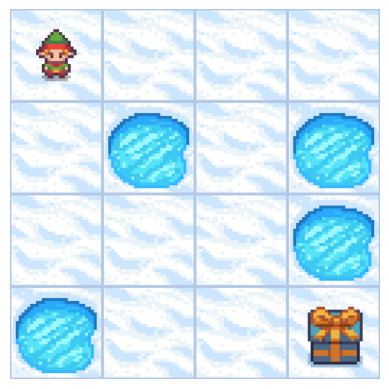

1


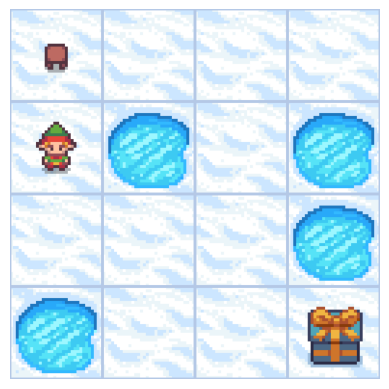

0


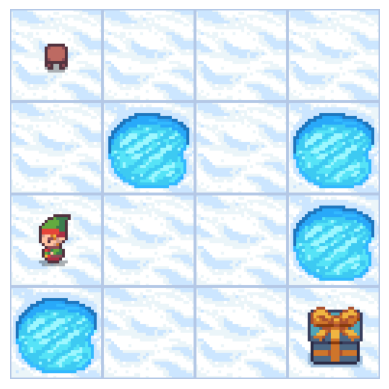

2


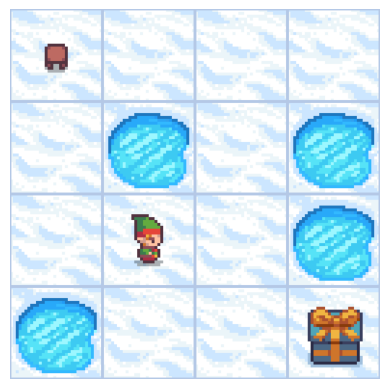

In [ ]:
# Ініціалізація середовища
observation = env.reset()

# Візуалізація середовища з режимом 'ansi'
show_render(env.render()[0])

# Взаємодія з середовищем
action = env.action_space.sample()  # Випадкова дія
print(action)
observation, reward, done, info = env.step(action)

# Візуалізація знову
show_render(env.render()[0])

# Взаємодія з середовищем
action = env.action_space.sample()  # Випадкова дія
print(action)
observation, reward, done, info = env.step(action)

# Візуалізація знову
show_render(env.render()[0])

# Взаємодія з середовищем
action = env.action_space.sample()  # Випадкова дія
print(action)
observation, reward, done, info = env.step(action)

# Візуалізація знову
show_render(env.render()[0])

# # Закриття середовища
# env.close()


In [ ]:
env.reset()

0

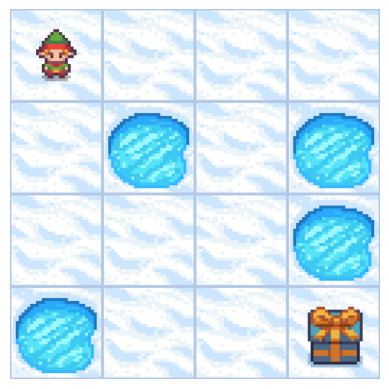

In [ ]:
show_render(env.render()[0])

0


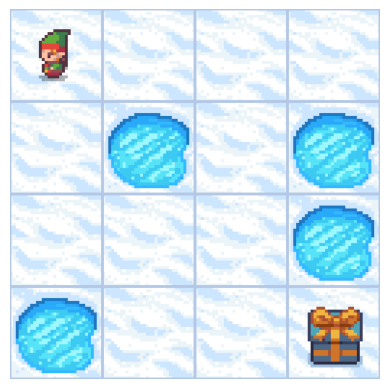

In [ ]:
action = 0  # Випадкова дія
print(action)
observation, reward, done, info = env.step(action)
# Візуалізація знову
show_render(env.render()[0])

Почнемо з дослідження середовища. Кількість можливих станів у середовищі — 16 (сітка 4 × 4):

In [ ]:
print(env.observation_space.n)

16


Кількість дій у середовищі дорівнює 4 (вгору, вниз, ліворуч і праворуч).

In [ ]:
print(env.action_space.n)

4


# Додаткові матеріали

1. Markov model NLP покроково - https://colab.research.google.com/drive/1tt-AFcIemBEynTasmSk58H706Yfuq40C?usp=sharing
2. Q-learning for beginners - https://towardsdatascience.com/q-learning-for-beginners-2837b777741
3. Hidden Markov Models: The Secret Sauce in Natural Language Processing - https://medium.com/@ompramod9921/hidden-markov-models-the-secret-sauce-in-natural-language-processing-98cde0372721
4. Understanding the Differences in Language Models - Transformers vs. Markov Models - https://safjan.com/understanding-differences-gpt-transformers-markov-models/
5. Understanding Language Modeling: From N-grams to Transformer-based Neural Models - https://medium.com/@roshmitadey/understanding-language-modeling-from-n-grams-to-transformer-based-neural-models-d2bdf1532c6d
6.  Лінк на книжку з Grokking D RL: https://github.com/DJDarkCyber/Data-Science-Books/blob/master/Grokking%20Deep%20Learning%20-%20MEAP%20v10.pdf
7. The Ultimate Beginner’s Guide to Reinforcement Learning - https://towardsdatascience.com/the-ultimate-beginners-guide-to-reinforcement-learning-588c071af1ec

